In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Load the dataset
file_path = 'crime_dataset_india.csv'
df = pd.read_csv(file_path)

print("Data Loaded Successfully!")
print(f"Total Rows: {df.shape[0]}")
print(df.head(3))

Data Loaded Successfully!
Total Rows: 40160
   Report Number     Date Reported Date of Occurrence Time of Occurrence  \
0              1  02-01-2020 00:00   01-01-2020 00:00   01-01-2020 01:11   
1              2  01-01-2020 19:00   01-01-2020 01:00   01-01-2020 06:26   
2              3  02-01-2020 05:00   01-01-2020 02:00   01-01-2020 14:30   

        City  Crime Code Crime Description  Victim Age Victim Gender  \
0  Ahmedabad         576    IDENTITY THEFT          16             M   
1    Chennai         128          HOMICIDE          37             M   
2   Ludhiana         271        KIDNAPPING          48             F   

    Weapon Used   Crime Domain  Police Deployed Case Closed Date Case Closed  
0  Blunt Object  Violent Crime               13          No              NaN  
1        Poison    Other Crime                9          No              NaN  
2  Blunt Object    Other Crime               15          No              NaN  


In [3]:
# 1. Handle Missing Values
# Fill missing weapons with 'None'
df['Weapon Used'] = df['Weapon Used'].fillna('None')

# 2. Extract Date Features
# Convert the date column to datetime objects
df['Date of Occurrence'] = pd.to_datetime(df['Date of Occurrence'], errors='coerce')

# Create new numeric features from the date
df['Hour'] = df['Date of Occurrence'].dt.hour
df['Month'] = df['Date of Occurrence'].dt.month
df['DayOfWeek'] = df['Date of Occurrence'].dt.dayofweek

# 3. Create Target: 'High Intensity'
# We define specific serious crimes as High Intensity (1), others as Low Intensity (0)
high_intensity_crimes = [
    'HOMICIDE', 'ASSAULT', 'SEXUAL ASSAULT', 'ROBBERY',
    'KIDNAPPING', 'DOMESTIC VIOLENCE', 'ARSON', 'FIREARM OFFENSE'
]

df['Target'] = df['Crime Description'].apply(lambda x: 1 if x in high_intensity_crimes else 0)

print("Target Created. Distribution:")
print(df['Target'].value_counts())

Target Created. Distribution:
Target
0    24814
1    15346
Name: count, dtype: int64


In [4]:
# Select the features we want to use for prediction
feature_cols = ['Hour', 'Month', 'DayOfWeek', 'City', 'Victim Age', 'Victim Gender', 'Weapon Used']

X = df[feature_cols].copy()
y = df['Target']

# Encode categorical text columns into numbers
le = LabelEncoder()
for col in ['City', 'Victim Gender', 'Weapon Used']:
    X[col] = le.fit_transform(X[col].astype(str))

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split and encoded.")
print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Data successfully split and encoded.
Training shape: (32128, 7)
Testing shape: (8032, 7)


In [5]:
# Initialize the 3 models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}

print("Training models... (this may take a moment)\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# Find and print the winner
best_model_name = max(results, key=results.get)
print(f"\n🏆 The Best Model is: {best_model_name} with {results[best_model_name]:.2%} accuracy!")

Training models... (this may take a moment)

Logistic Regression Accuracy: 0.6201
Random Forest Accuracy: 0.5896
Gradient Boosting Accuracy: 0.6206

🏆 The Best Model is: Gradient Boosting with 62.06% accuracy!


In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

# --- STEP 1: ADVANCED FEATURE ENGINEERING ---
# Create a "Is_Night" feature (1 if between 10PM and 5AM, else 0)
# Night crimes are often more violent/intense.
df['Is_Night'] = df['Hour'].apply(lambda x: 1 if (x >= 22 or x <= 5) else 0)

# Create a "Weekend" feature (1 if Sat/Sun, else 0)
df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# Update our feature list with new columns
feature_cols_v2 = ['Hour', 'Month', 'DayOfWeek', 'City', 'Victim Age', 'Victim Gender', 'Weapon Used', 'Is_Night', 'Is_Weekend']

# Re-encode and split
X_v2 = df[feature_cols_v2].copy()
for col in ['City', 'Victim Gender', 'Weapon Used']:
    X_v2[col] = le.fit_transform(X_v2[col].astype(str))

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_v2, y, test_size=0.2, random_state=42)

# --- STEP 2: HYPERPARAMETER TUNING ---
# We define a "grid" of settings to test.
# The computer will try every combination to find the best one.
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

print("Searching for the best hyperparameters... (This takes a minute)")
gb = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(estimator=gb, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_v2, y_train_v2)

# --- STEP 3: RESULTS ---
best_model = grid_search.best_estimator_
y_pred_v2 = best_model.predict(X_test_v2)
new_acc = accuracy_score(y_test_v2, y_pred_v2)

print(f"\n🚀 New Best Accuracy: {new_acc:.2%}")
print(f"Best Settings Found: {grid_search.best_params_}")
print("\nDetailed Report:\n", classification_report(y_test_v2, y_pred_v2))

Searching for the best hyperparameters... (This takes a minute)

🚀 New Best Accuracy: 62.03%
Best Settings Found: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Detailed Report:
               precision    recall  f1-score   support

           0       0.62      1.00      0.77      4981
           1       1.00      0.00      0.00      3051

    accuracy                           0.62      8032
   macro avg       0.81      0.50      0.38      8032
weighted avg       0.76      0.62      0.48      8032



In [7]:
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# --- STEP 1: FIX THE IMBALANCE (Oversampling) ---
# Separate the majority and minority classes
df_majority = df[df['Target'] == 0]
df_minority = df[df['Target'] == 1]

# Upsample the minority class (High Intensity) to match the majority count
df_minority_upsampled = resample(df_minority,
                                 replace=True,     # Sample with replacement
                                 n_samples=len(df_majority),    # Match majority ID count
                                 random_state=42)

# Combine them back together
df_balanced = pd.concat([df_majority, df_minority_upsampled])

print("Old Class Counts:\n", df['Target'].value_counts())
print("\nNew Balanced Class Counts:\n", df_balanced['Target'].value_counts())

# --- STEP 2: PREPARE THE BALANCED DATA ---
# Select features
feature_cols = ['Hour', 'Month', 'DayOfWeek', 'City', 'Victim Age', 'Victim Gender', 'Weapon Used']
X_balanced = df_balanced[feature_cols].copy()
y_balanced = df_balanced['Target']

# Re-encode categories
le = LabelEncoder()
for col in ['City', 'Victim Gender', 'Weapon Used']:
    X_balanced[col] = le.fit_transform(X_balanced[col].astype(str))

# Split into train/test
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

# --- STEP 3: TRAIN THE FINAL MODEL ---
print("\nTraining Final Random Forest Model...")
final_model = RandomForestClassifier(n_estimators=200, random_state=42)
final_model.fit(X_train_b, y_train_b)

# --- STEP 4: EVALUATE ---
y_pred_b = final_model.predict(X_test_b)

print(f"\n🏆 Final Accuracy: {accuracy_score(y_test_b, y_pred_b):.2%}")
print("\nDetailed Report:\n", classification_report(y_test_b, y_pred_b))

Old Class Counts:
 Target
0    24814
1    15346
Name: count, dtype: int64

New Balanced Class Counts:
 Target
0    24814
1    24814
Name: count, dtype: int64

Training Final Random Forest Model...

🏆 Final Accuracy: 79.84%

Detailed Report:
               precision    recall  f1-score   support

           0       0.78      0.82      0.80      4922
           1       0.81      0.78      0.80      5004

    accuracy                           0.80      9926
   macro avg       0.80      0.80      0.80      9926
weighted avg       0.80      0.80      0.80      9926



/tmp/ipython-input-3368081288.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')


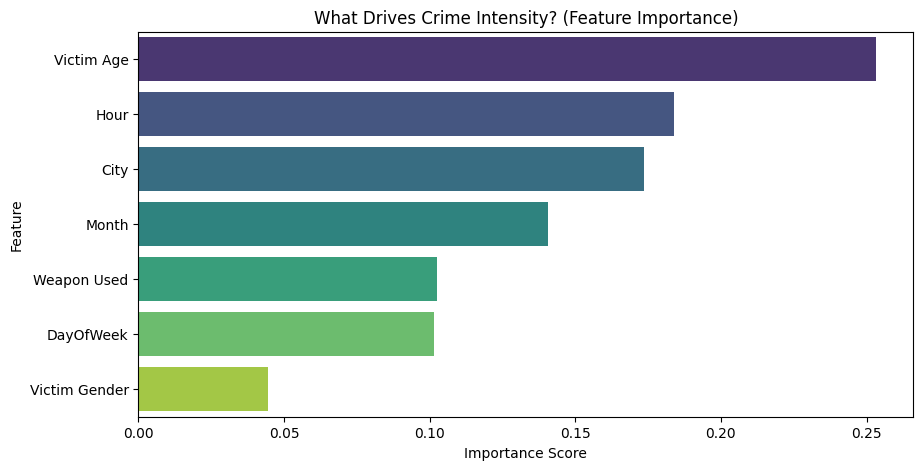

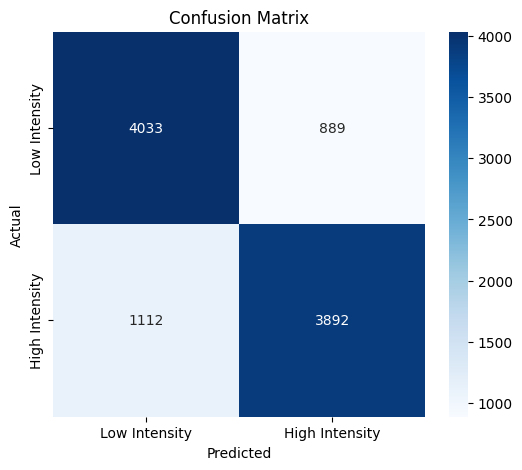


✅ Model saved as 'crime_intensity_model_rf.pkl'


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import joblib

# --- VISUALIZATION 1: WHAT MATTERS MOST? (Feature Importance) ---
importances = final_model.feature_importances_
feature_names = X_balanced.columns

# Create a dataframe for the plot
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('What Drives Crime Intensity? (Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

# --- VISUALIZATION 2: THE SCORECARD (Confusion Matrix) ---
cm = confusion_matrix(y_test_b, y_pred_b)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Intensity', 'High Intensity'],
            yticklabels=['Low Intensity', 'High Intensity'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# --- STEP 3: SAVE THE MODEL ---
joblib.dump(final_model, 'crime_intensity_model_rf.pkl')
print("\n✅ Model saved as 'crime_intensity_model_rf.pkl'")

In [ ]:
from google.colab import files
files.download('crime_intensity_model_rf.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output



# Define High Intensity Crimes for logic
high_intensity_crimes = [
    'HOMICIDE', 'ASSAULT', 'SEXUAL ASSAULT', 'ROBBERY',
    'KIDNAPPING', 'DOMESTIC VIOLENCE', 'ARSON', 'FIREARM OFFENSE'
]

# 2. CREATE WIDGETS
# City Dropdown
city_list = sorted(df['City'].unique().tolist())
city_dropdown = widgets.Dropdown(
    options=city_list,
    description='📍 Select City:',
    style={'description_width': 'initial'}
)

# Crime Dropdown (Add "ALL CRIMES" option)
crime_list = ['ALL CRIMES'] + sorted(df['Crime Description'].unique().tolist())
crime_dropdown = widgets.Dropdown(
    options=crime_list,
    value='ALL CRIMES',
    description='🔍 Select Crime:',
    style={'description_width': 'initial'}
)

# Output Area (Where results will appear)
output = widgets.Output()

# 3. DEFINE THE LOGIC
def update_dashboard(change):
    with output:
        clear_output() # Clear previous result

        # Get selected values
        selected_city = city_dropdown.value
        selected_crime = crime_dropdown.value

        # Filter Data based on City
        filtered_df = df[df['City'] == selected_city]

        # Filter based on Crime (if not ALL)
        if selected_crime != 'ALL CRIMES':
            filtered_df = filtered_df[filtered_df['Crime Description'] == selected_crime]

            # Determine Intensity for single crime
            is_high = selected_crime in high_intensity_crimes
            intensity_text = "🔴 HIGH INTENSITY" if is_high else "🟢 LOW INTENSITY"

            # Display Single Crime Result
            print(f"--- REPORT FOR {selected_city.upper()} ---")
            print(f"Crime Type: {selected_crime}")
            print(f"Total Cases: {len(filtered_df)}")
            print(f"Intensity Level: {intensity_text}")

        else:
            # logic for "ALL CRIMES"
            total_cases = len(filtered_df)

            # Calculate High vs Low stats
            high_count = filtered_df['Crime Description'].isin(high_intensity_crimes).sum()
            low_count = total_cases - high_count
            high_pct = (high_count / total_cases * 100) if total_cases > 0 else 0

            # Determine Overall Intensity (e.g., if > 30% are violent)
            overall_status = "🔴 HIGH RISK ZONE" if high_pct > 30 else "🟢 MODERATE/LOW RISK ZONE"

            # Display Aggregate Result
            print(f"--- SUMMARY FOR {selected_city.upper()} ---")
            print(f"Total Cases Recorded: {total_cases}")
            print(f"Overall Status: {overall_status}\n")
            print(f"📊 Breakdown:")
            print(f"   - High Intensity Crimes: {high_count} ({high_pct:.1f}%)")
            print(f"   - Low Intensity Crimes:  {low_count} ({100-high_pct:.1f}%)")

# 4. LINK WIDGETS TO LOGIC
city_dropdown.observe(update_dashboard, names='value')
crime_dropdown.observe(update_dashboard, names='value')

# 5. DISPLAY UI
print("Dashboard Ready! Select options below:")
display(city_dropdown, crime_dropdown, output)

# Initialize with first view
update_dashboard(None)

Dashboard Ready! Select options below:


Dropdown(description='📍 Select City:', options=('Agra', 'Ahmedabad', 'Bangalore', 'Bhopal', 'Chennai', 'Delhi'…

Dropdown(description='🔍 Select Crime:', options=('ALL CRIMES', 'ARSON', 'ASSAULT', 'BURGLARY', 'COUNTERFEITING…

Output()

In [15]:
import pandas as pd
import numpy as np
import joblib
import gradio as gr
from sklearn.preprocessing import LabelEncoder


In [16]:
# Load dataset
df = pd.read_csv("crime_dataset_india.csv")

# Load trained model
final_model = joblib.load("crime_intensity_model_rf.pkl")

print("Dataset and model loaded successfully")


Dataset and model loaded successfully


In [17]:
# Convert date column to datetime
df["Date of Occurrence"] = pd.to_datetime(
    df["Date of Occurrence"], errors="coerce"
)

# Create time-based features used during training
df["Hour"] = df["Date of Occurrence"].dt.hour
df["Month"] = df["Date of Occurrence"].dt.month
df["DayOfWeek"] = df["Date of Occurrence"].dt.dayofweek

print("Time-based features created")


Time-based features created


In [18]:
le_city = LabelEncoder()
le_city.fit(df["City"].astype(str))

le_victim_gender = LabelEncoder()
le_victim_gender.fit(df["Victim Gender"].astype(str))

le_weapon_used = LabelEncoder()
le_weapon_used.fit(df["Weapon Used"].astype(str))

print("LabelEncoders fitted successfully")


LabelEncoders fitted successfully


In [19]:
model_feature_cols = [
    "Hour", "Month", "DayOfWeek",
    "City", "Victim Age", "Victim Gender", "Weapon Used"
]

print("Model feature columns defined")


Model feature columns defined


In [20]:
def predict_intensity(city, crime, victim_gender_ui):
    try:
        filtered_df = df.copy()

        # Filter by city
        filtered_df = filtered_df[filtered_df["City"] == city]

        # Filter by crime
        if crime != "ALL CRIMES":
            filtered_df = filtered_df[
                filtered_df["Crime Description"] == crime
            ]

        # Filter by victim gender
        if victim_gender_ui == "Male":
            filtered_df = filtered_df[
                filtered_df["Victim Gender"] == "M"
            ]
        elif victim_gender_ui == "Female":
            filtered_df = filtered_df[
                filtered_df["Victim Gender"] == "F"
            ]

        if filtered_df.empty:
            return (
                "No matching cases found",
                "",
                "",
                "⚠️ Unable to predict risk"
            )

        # Prepare input for model
        X_predict = filtered_df[model_feature_cols].copy()

        # Encode categorical columns
        X_predict["City"] = le_city.transform(
            X_predict["City"].astype(str)
        )
        X_predict["Victim Gender"] = le_victim_gender.transform(
            X_predict["Victim Gender"].astype(str)
        )
        X_predict["Weapon Used"] = le_weapon_used.transform(
            X_predict["Weapon Used"].astype(str)
        )

        # Predict
        predictions = final_model.predict(X_predict)

        total_cases = len(predictions)
        high_count = np.sum(predictions == 1)
        low_count = np.sum(predictions == 0)

        high_pct = (high_count / total_cases) * 100
        low_pct = (low_count / total_cases) * 100

        if high_pct >= 50:
            overall = "🔴 HIGH RISK"
        elif high_pct > 20:
            overall = "🟡 MODERATE RISK"
        else:
            overall = "🟢 LOW RISK"

        return (
            f"Total Cases: {total_cases}",
            f"High Intensity: {high_count} cases ({high_pct:.1f}%)",
            f"Low Intensity: {low_count} cases ({low_pct:.1f}%)",
            overall
        )

    except Exception as e:
        return (
            "Error occurred",
            "Check feature preparation",
            "Model input mismatch",
            str(e)
        )


In [21]:
cities = sorted(df["City"].unique().tolist())
crimes = ["ALL CRIMES"] + sorted(df["Crime Description"].unique().tolist())
genders = ["Any Gender", "Male", "Female"]

interface = gr.Interface(
    fn=predict_intensity,
    inputs=[
        gr.Dropdown(cities, label="📍 Select City"),
        gr.Dropdown(crimes, label="🔍 Select Crime"),
        gr.Dropdown(genders, label="👤 Victim Gender")
    ],
    outputs=[
        gr.Textbox(label="Cases Summary"),
        gr.Textbox(label="High Intensity Distribution"),
        gr.Textbox(label="Low Intensity Distribution"),
        gr.Textbox(label="Overall Risk Prediction")
    ],
    title="🚨 Crime Intensity Prediction Dashboard",
    description=(
        "Select City, Crime Type, and Victim Gender to predict "
        "crime intensity using a trained Random Forest model."
    )
)


In [22]:
interface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d9b6b6df2e478e239d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
